In [1]:
import numpy as np
import matplotlib.pyplot as plt
import src.routines.tomo_fusion.tools.plotting_fcts as tomo_plots
from src.routines.rt_roi_prad import RtPradROI

/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarn

In [2]:
rt_prad = RtPradROI(shot_nb=85270, downsample=False)

In [3]:
liuqe_time = rt_prad.data['liuqe_time'].flatten()
fbte_time = rt_prad.data['fbte_time'].flatten()

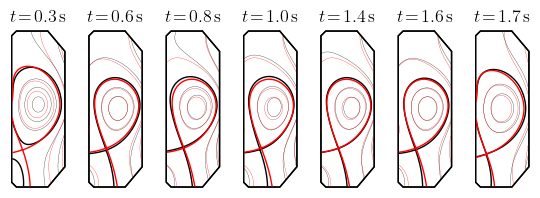

In [6]:
fig,ax=plt.subplots(1,7, figsize=(6.7,2.7), width_ratios=[1,1,1,1,1,1,1])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})
plt.subplots_adjust(wspace=0.4)

idxs_to_be_plotted_fbt = np.array([13,17,20,21,22,25,28])
idxs_to_be_plotted_liuqe = np.zeros(7, dtype=int)
for i in range(7):
    idx_closest = np.argmin(np.abs(liuqe_time-fbte_time[idxs_to_be_plotted_fbt[i]]))
    idxs_to_be_plotted_liuqe[i] = idx_closest
#idxs_to_be_plotted_liuqe = np.array([10,20,30,40,50,60,70])#296
levels=5
titles = [r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[0]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[1]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[2]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[3]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[4]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[5]]),
          r"$t\!=\!{:.1f}\,\mathrm{{s}}$".format(fbte_time[idxs_to_be_plotted_fbt[6]])]

for i, idx in enumerate(idxs_to_be_plotted_liuqe):
    tomo_plots.plot_profile(np.ones((rt_prad.Nz, rt_prad.Nr)), tcv_plot_clip=True, contour_image=rt_prad.liuqe_eqs[idx, :, :],
                         ax=ax[i], colorbar=False, cmap="gray", contour_color="k", vmin=0, vmax=1, aspect=None, levels=levels, lcfs_width=1)
for i, idx in enumerate(idxs_to_be_plotted_fbt):
    tomo_plots.plot_profile(np.ones((rt_prad.Nz, rt_prad.Nr)), tcv_plot_clip=True, contour_image=rt_prad.fbte_eqs[idx, :, :],
                         ax=ax[i], colorbar=False, cmap="gray", contour_color="r", vmin=0, vmax=1, aspect=None, levels=levels, lcfs_width=1)
    ax[i].set_title(titles[i], fontsize=13)
    

#plt.savefig('figures/fbt_vs_liuqe.eps', format='eps', bbox_inches="tight")

plt.show()